/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/notebooks


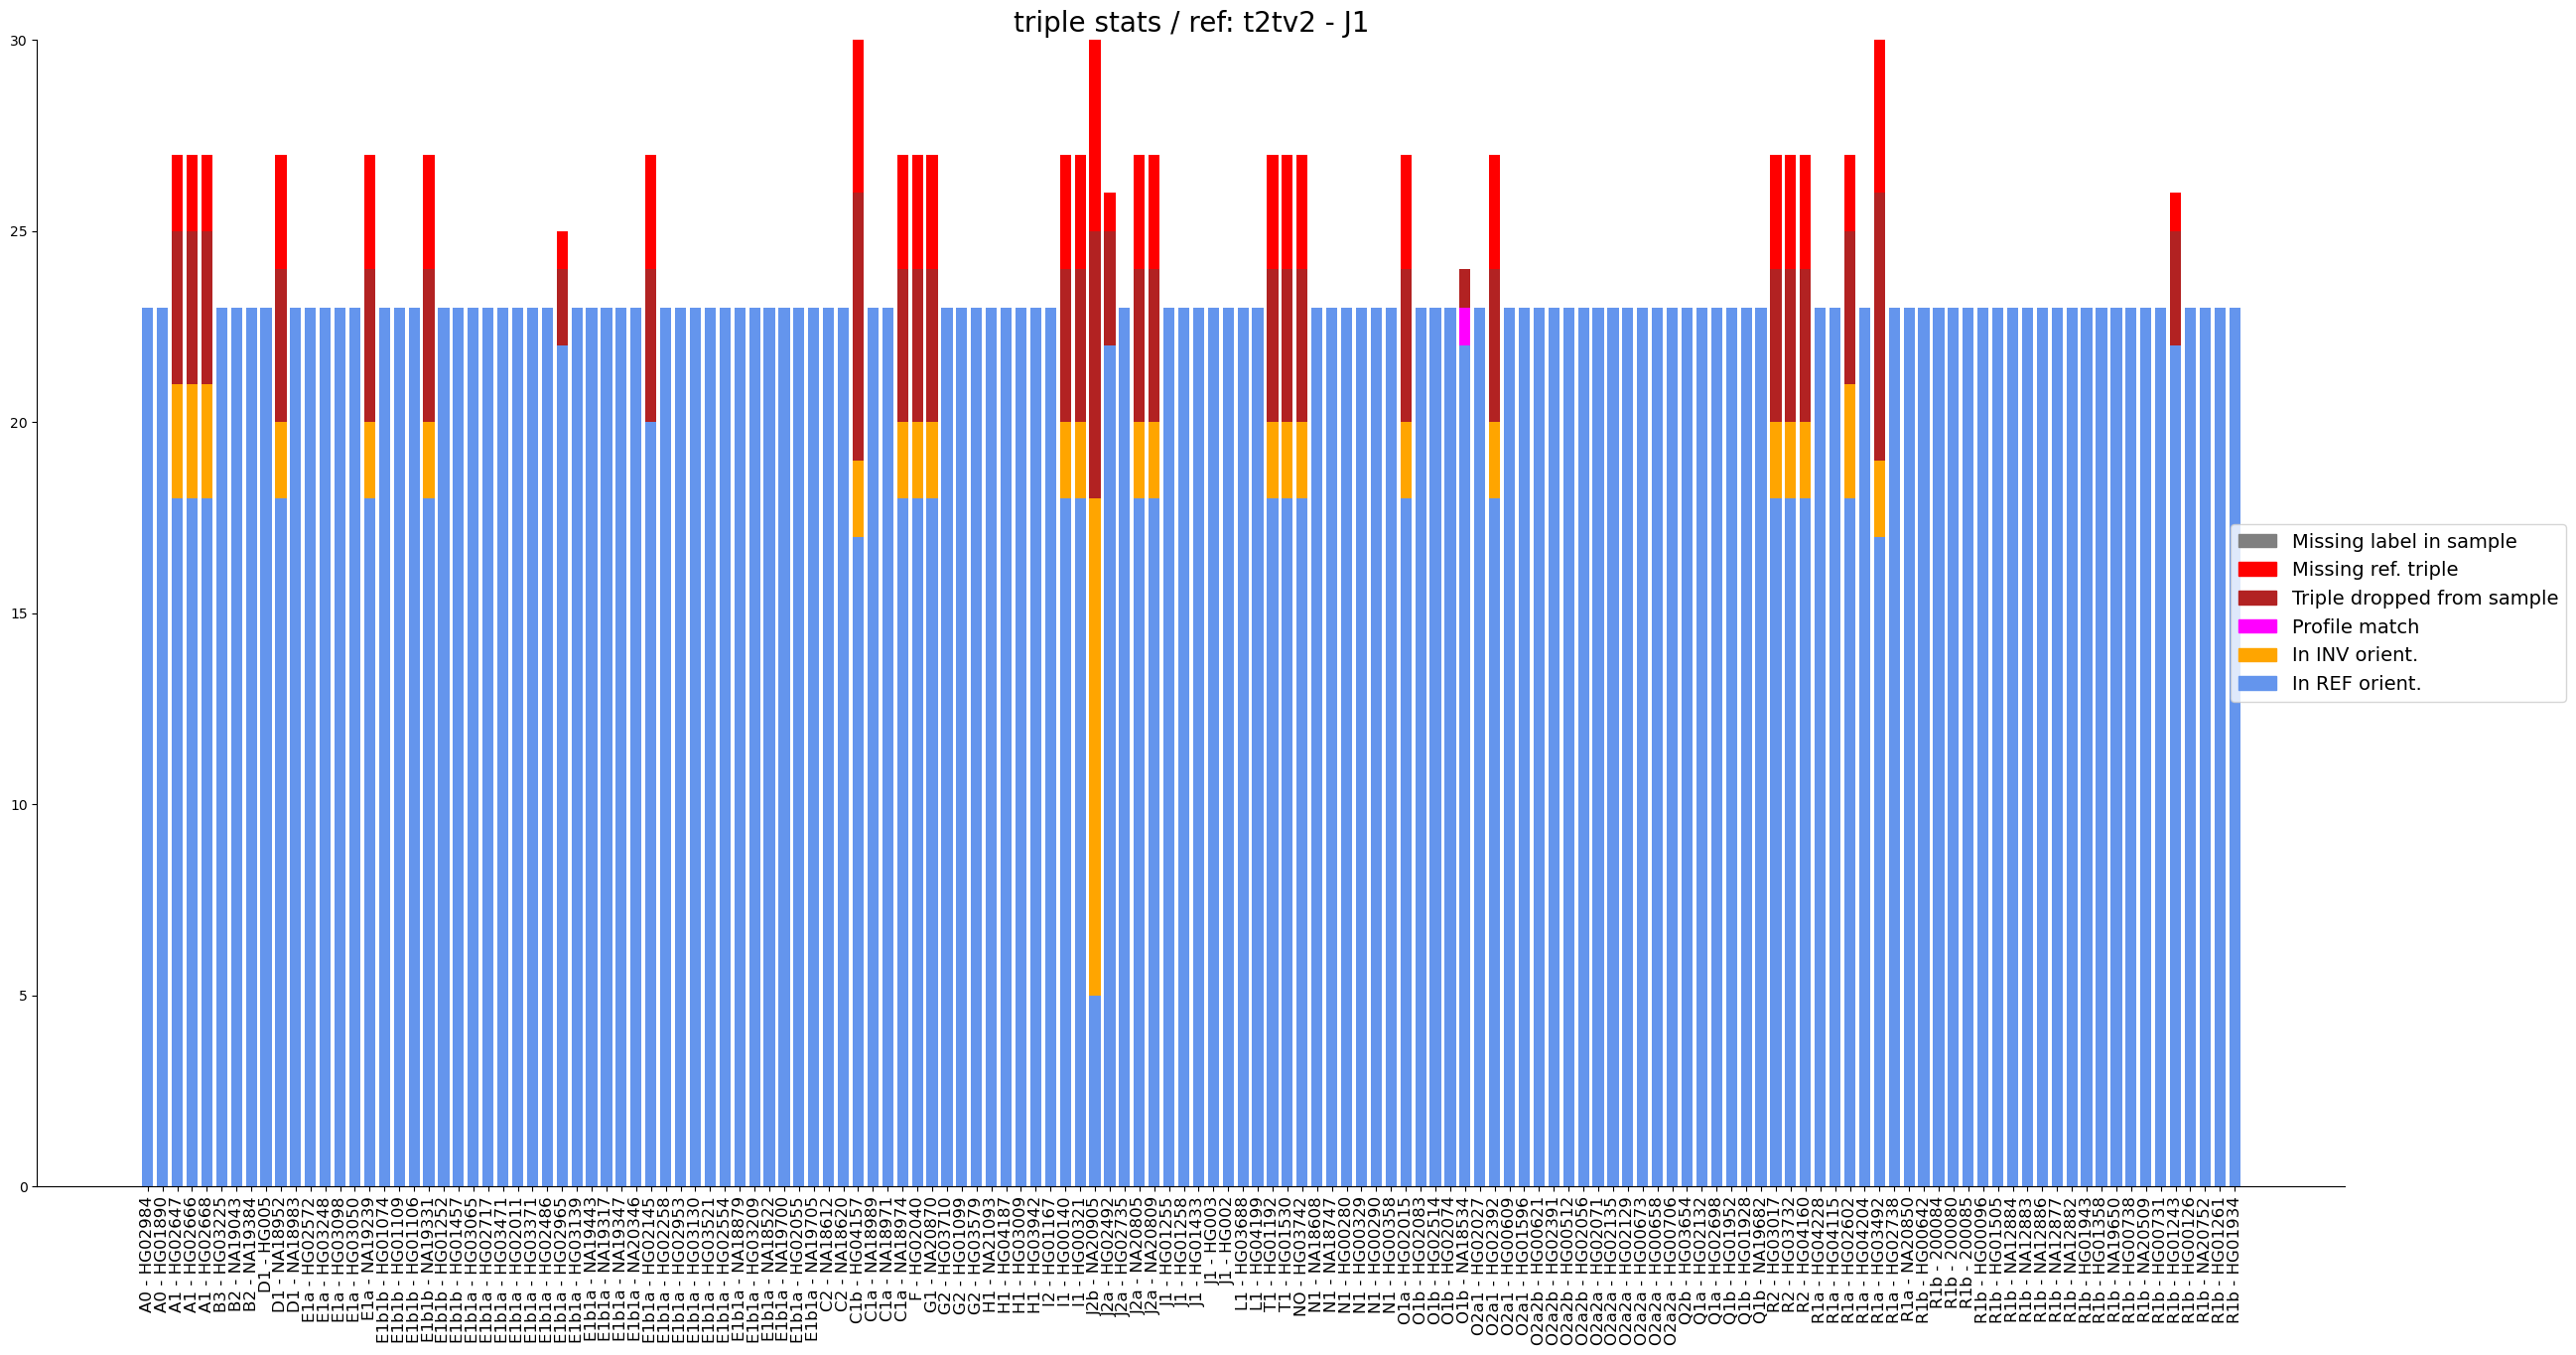

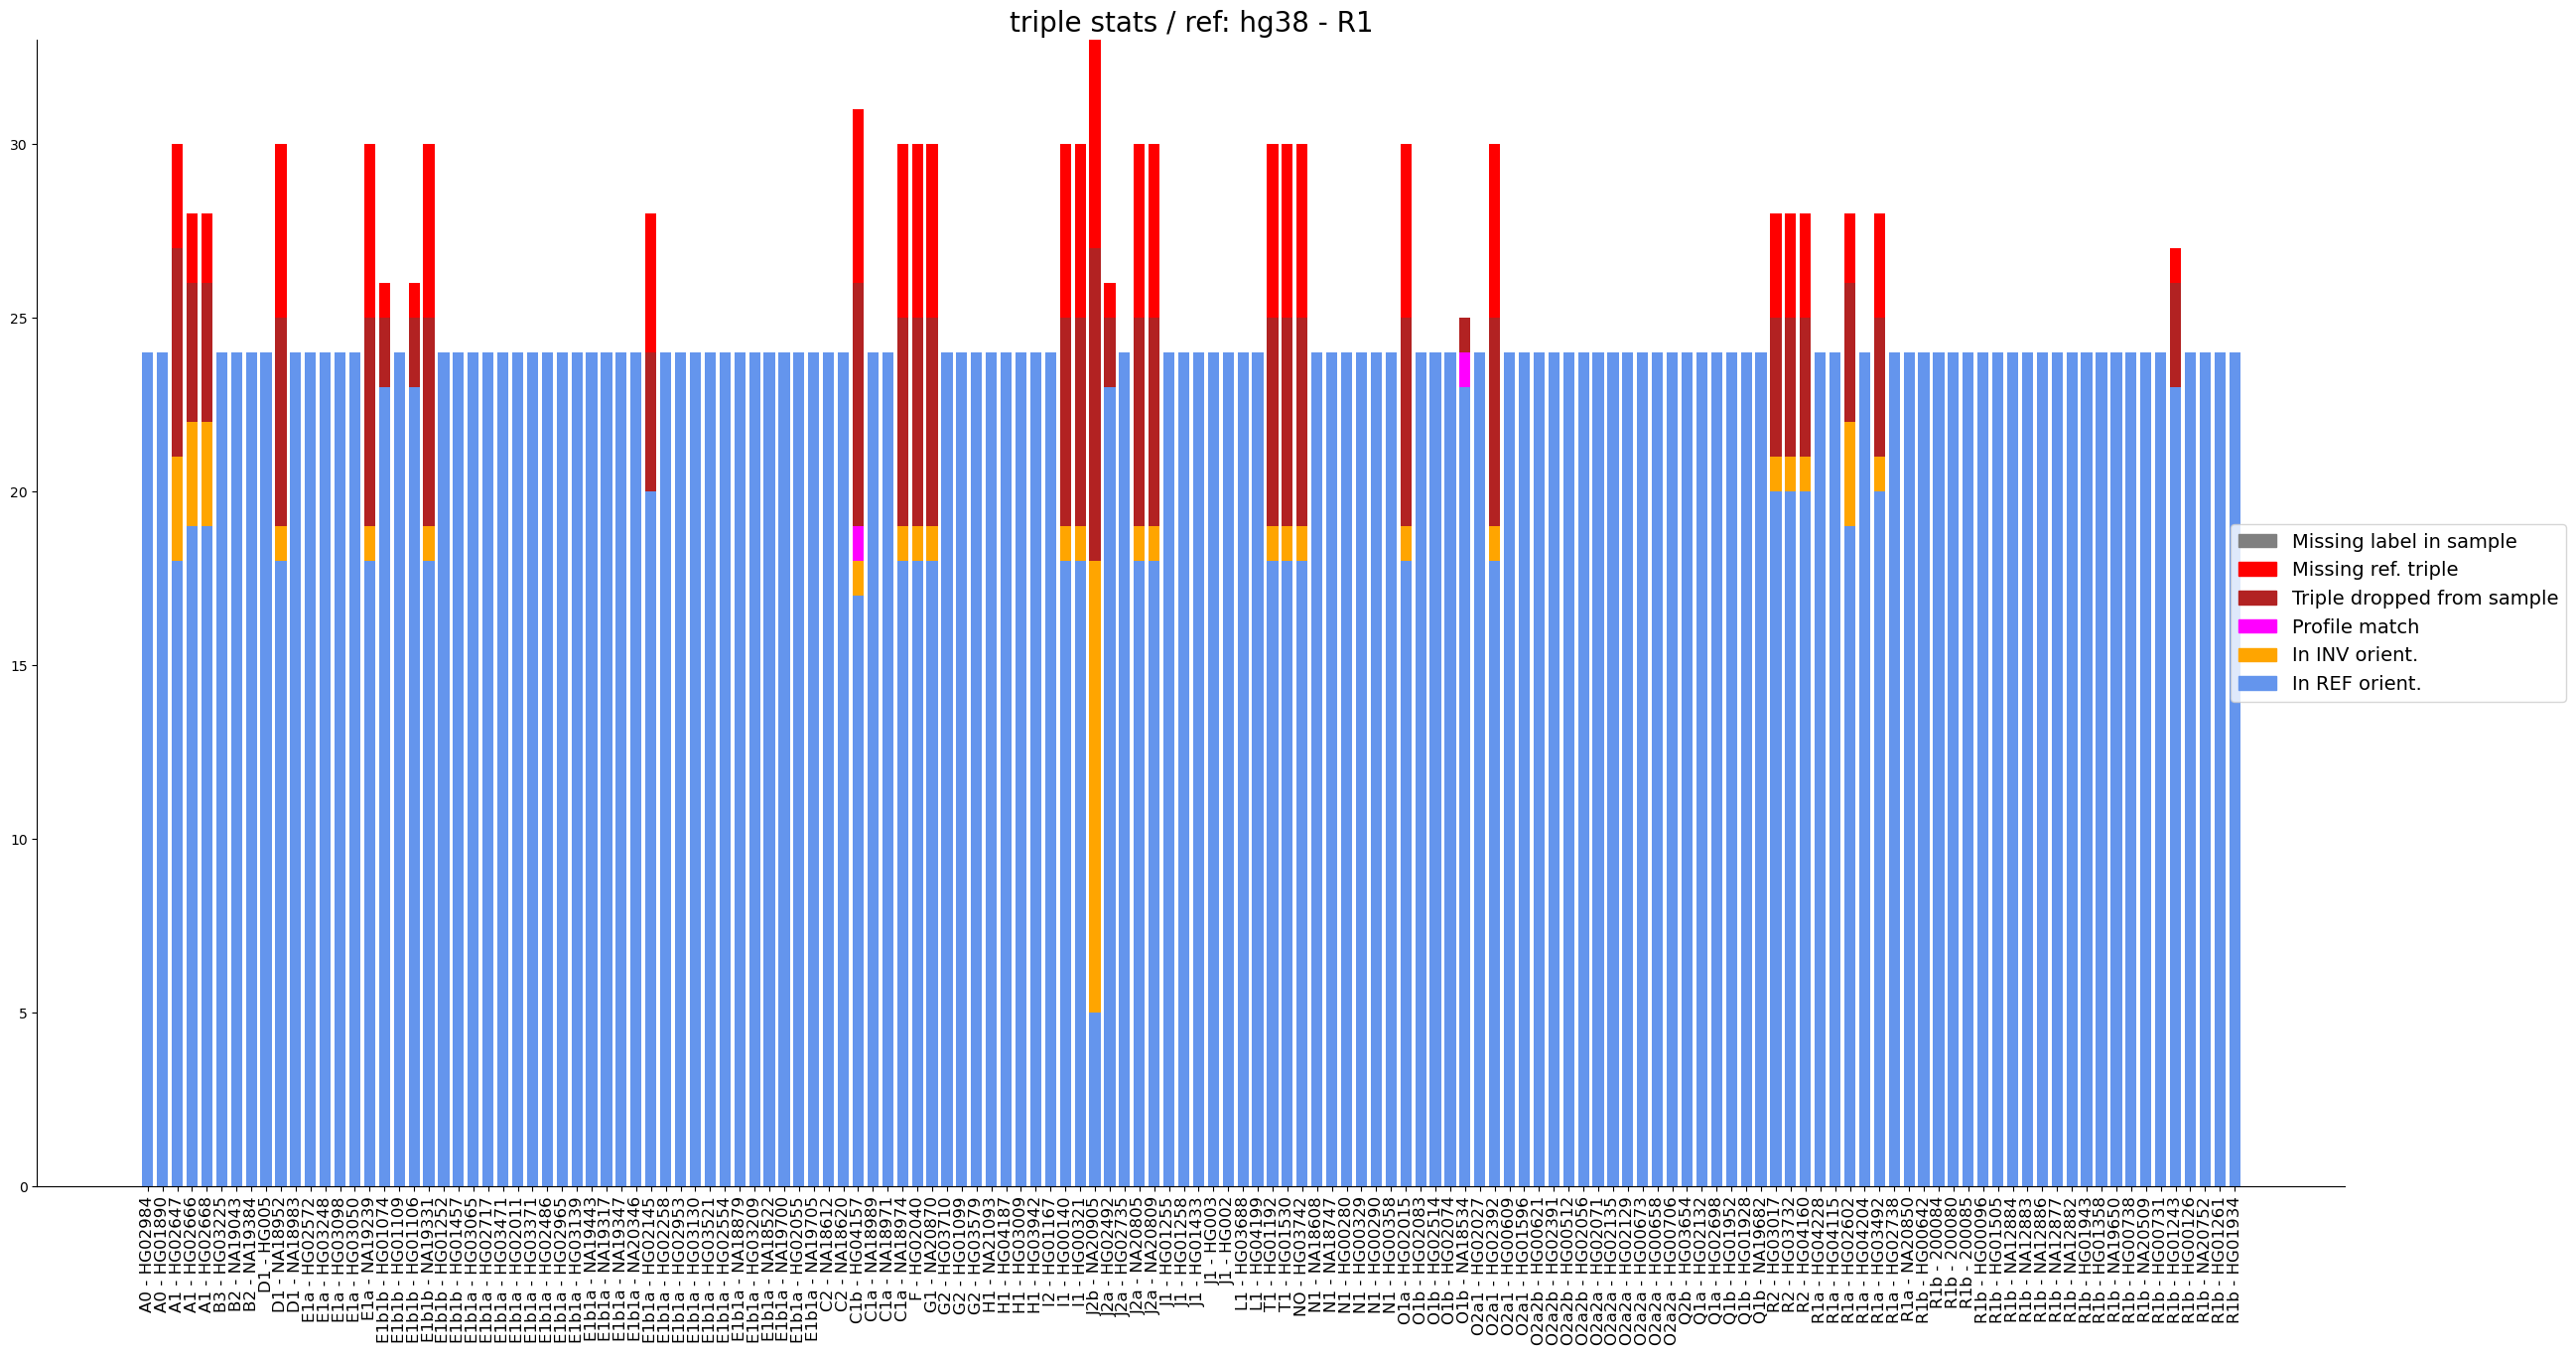

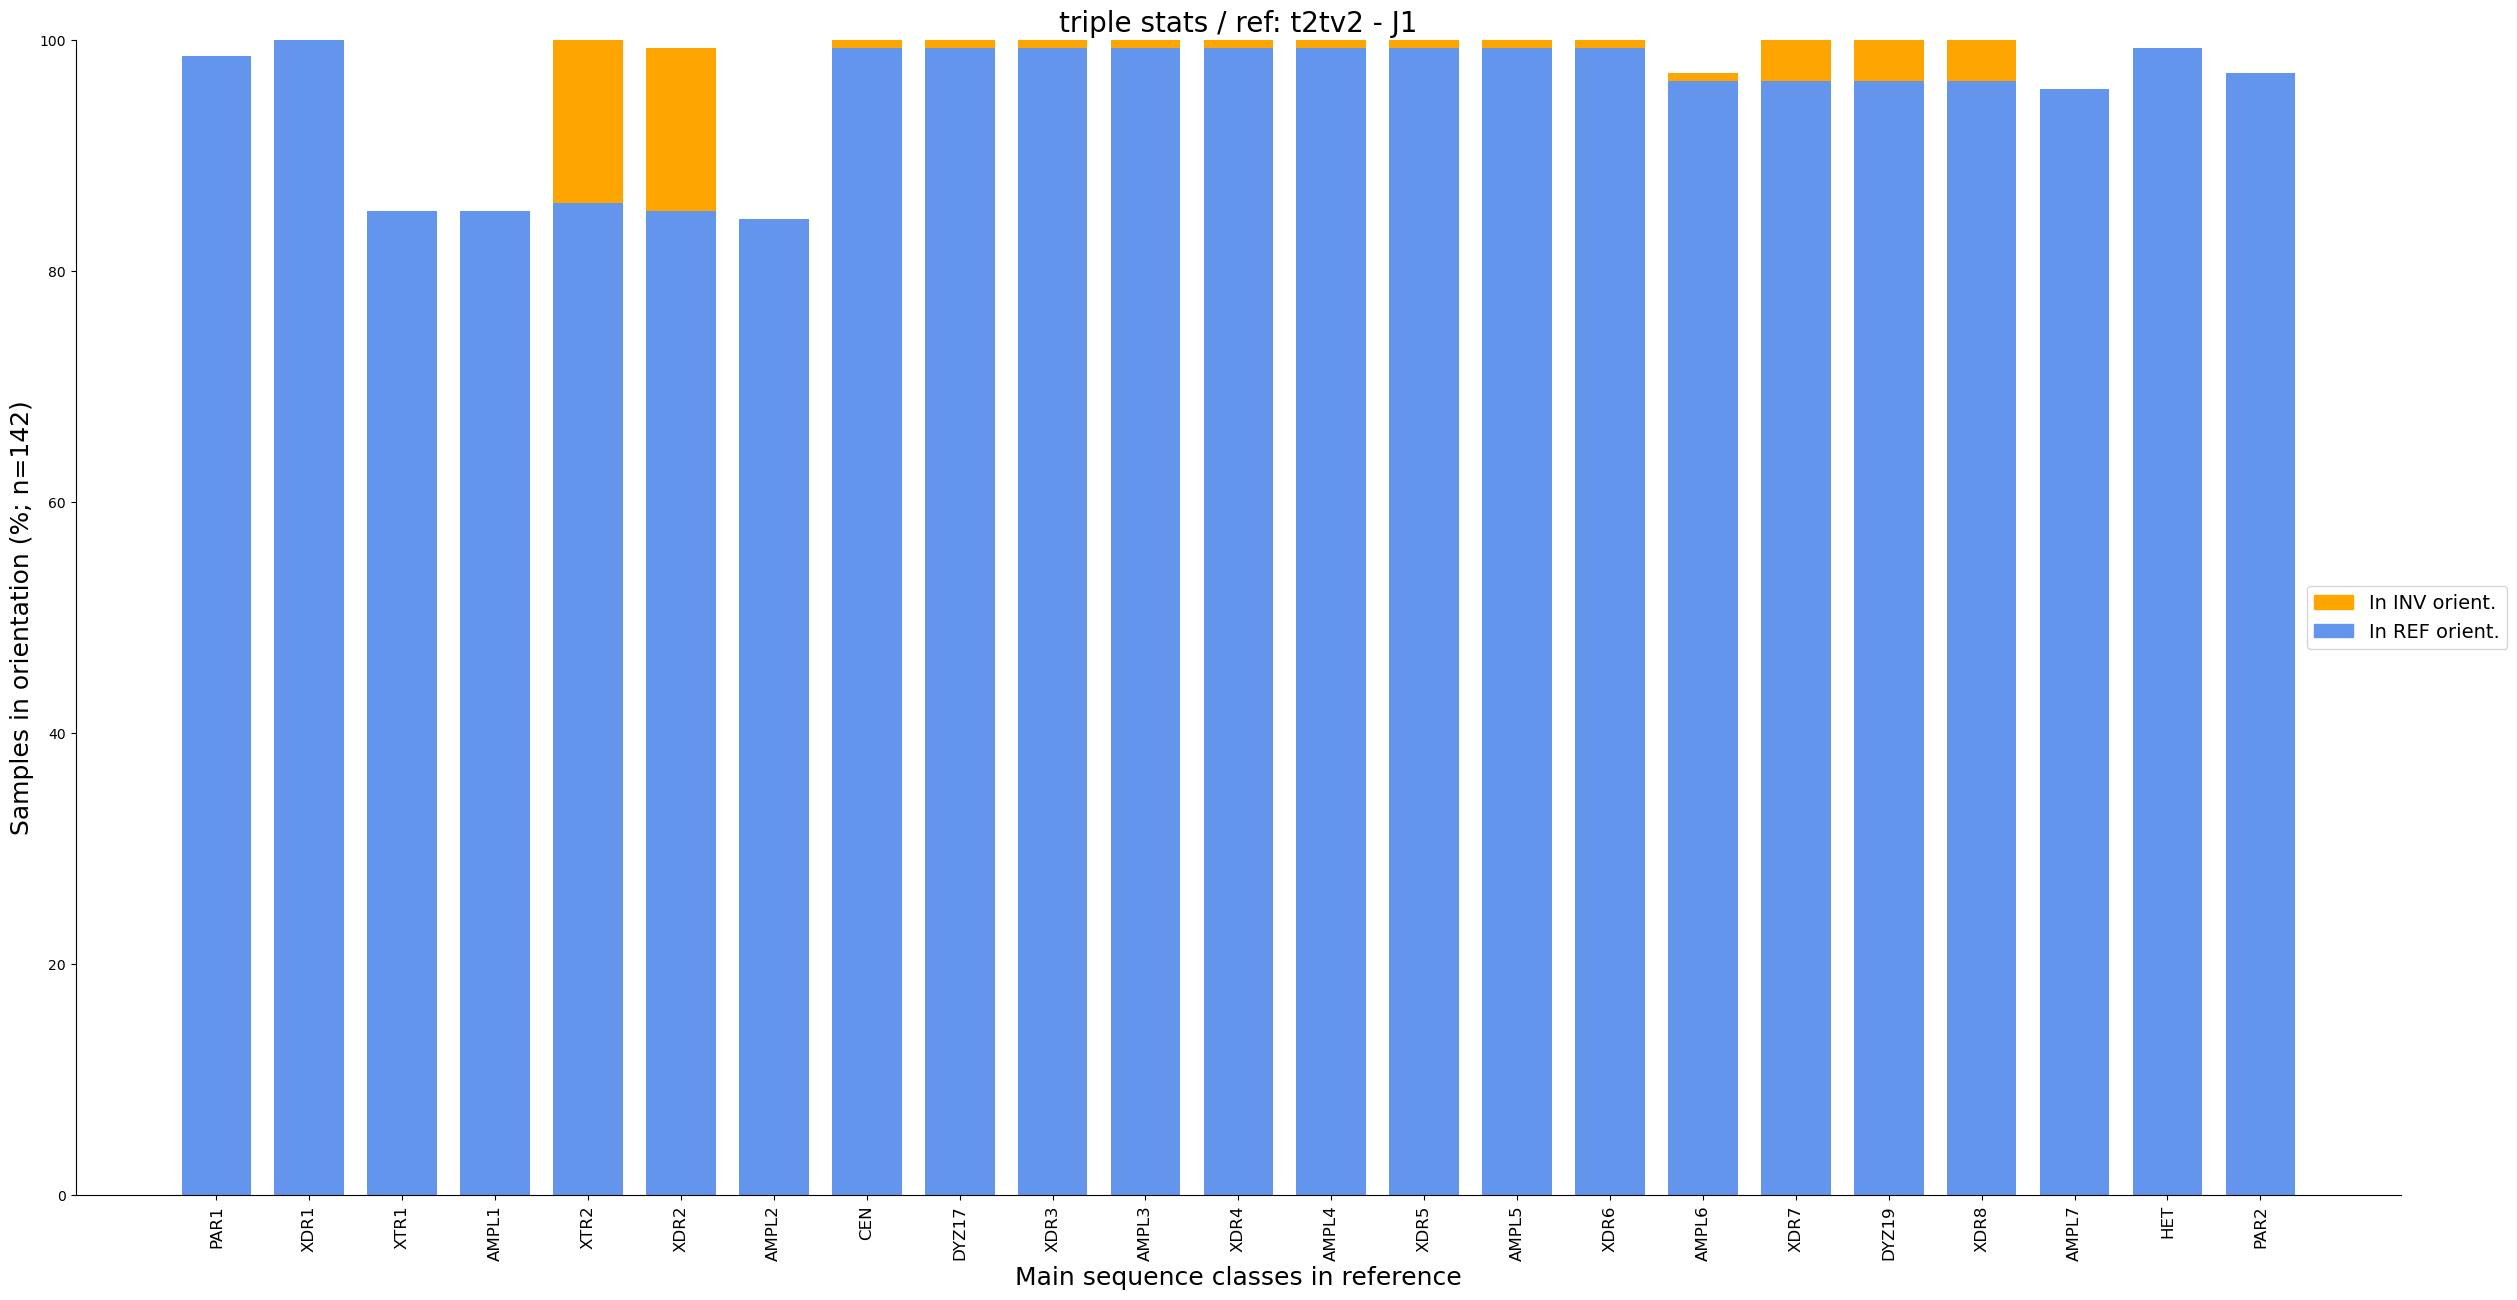

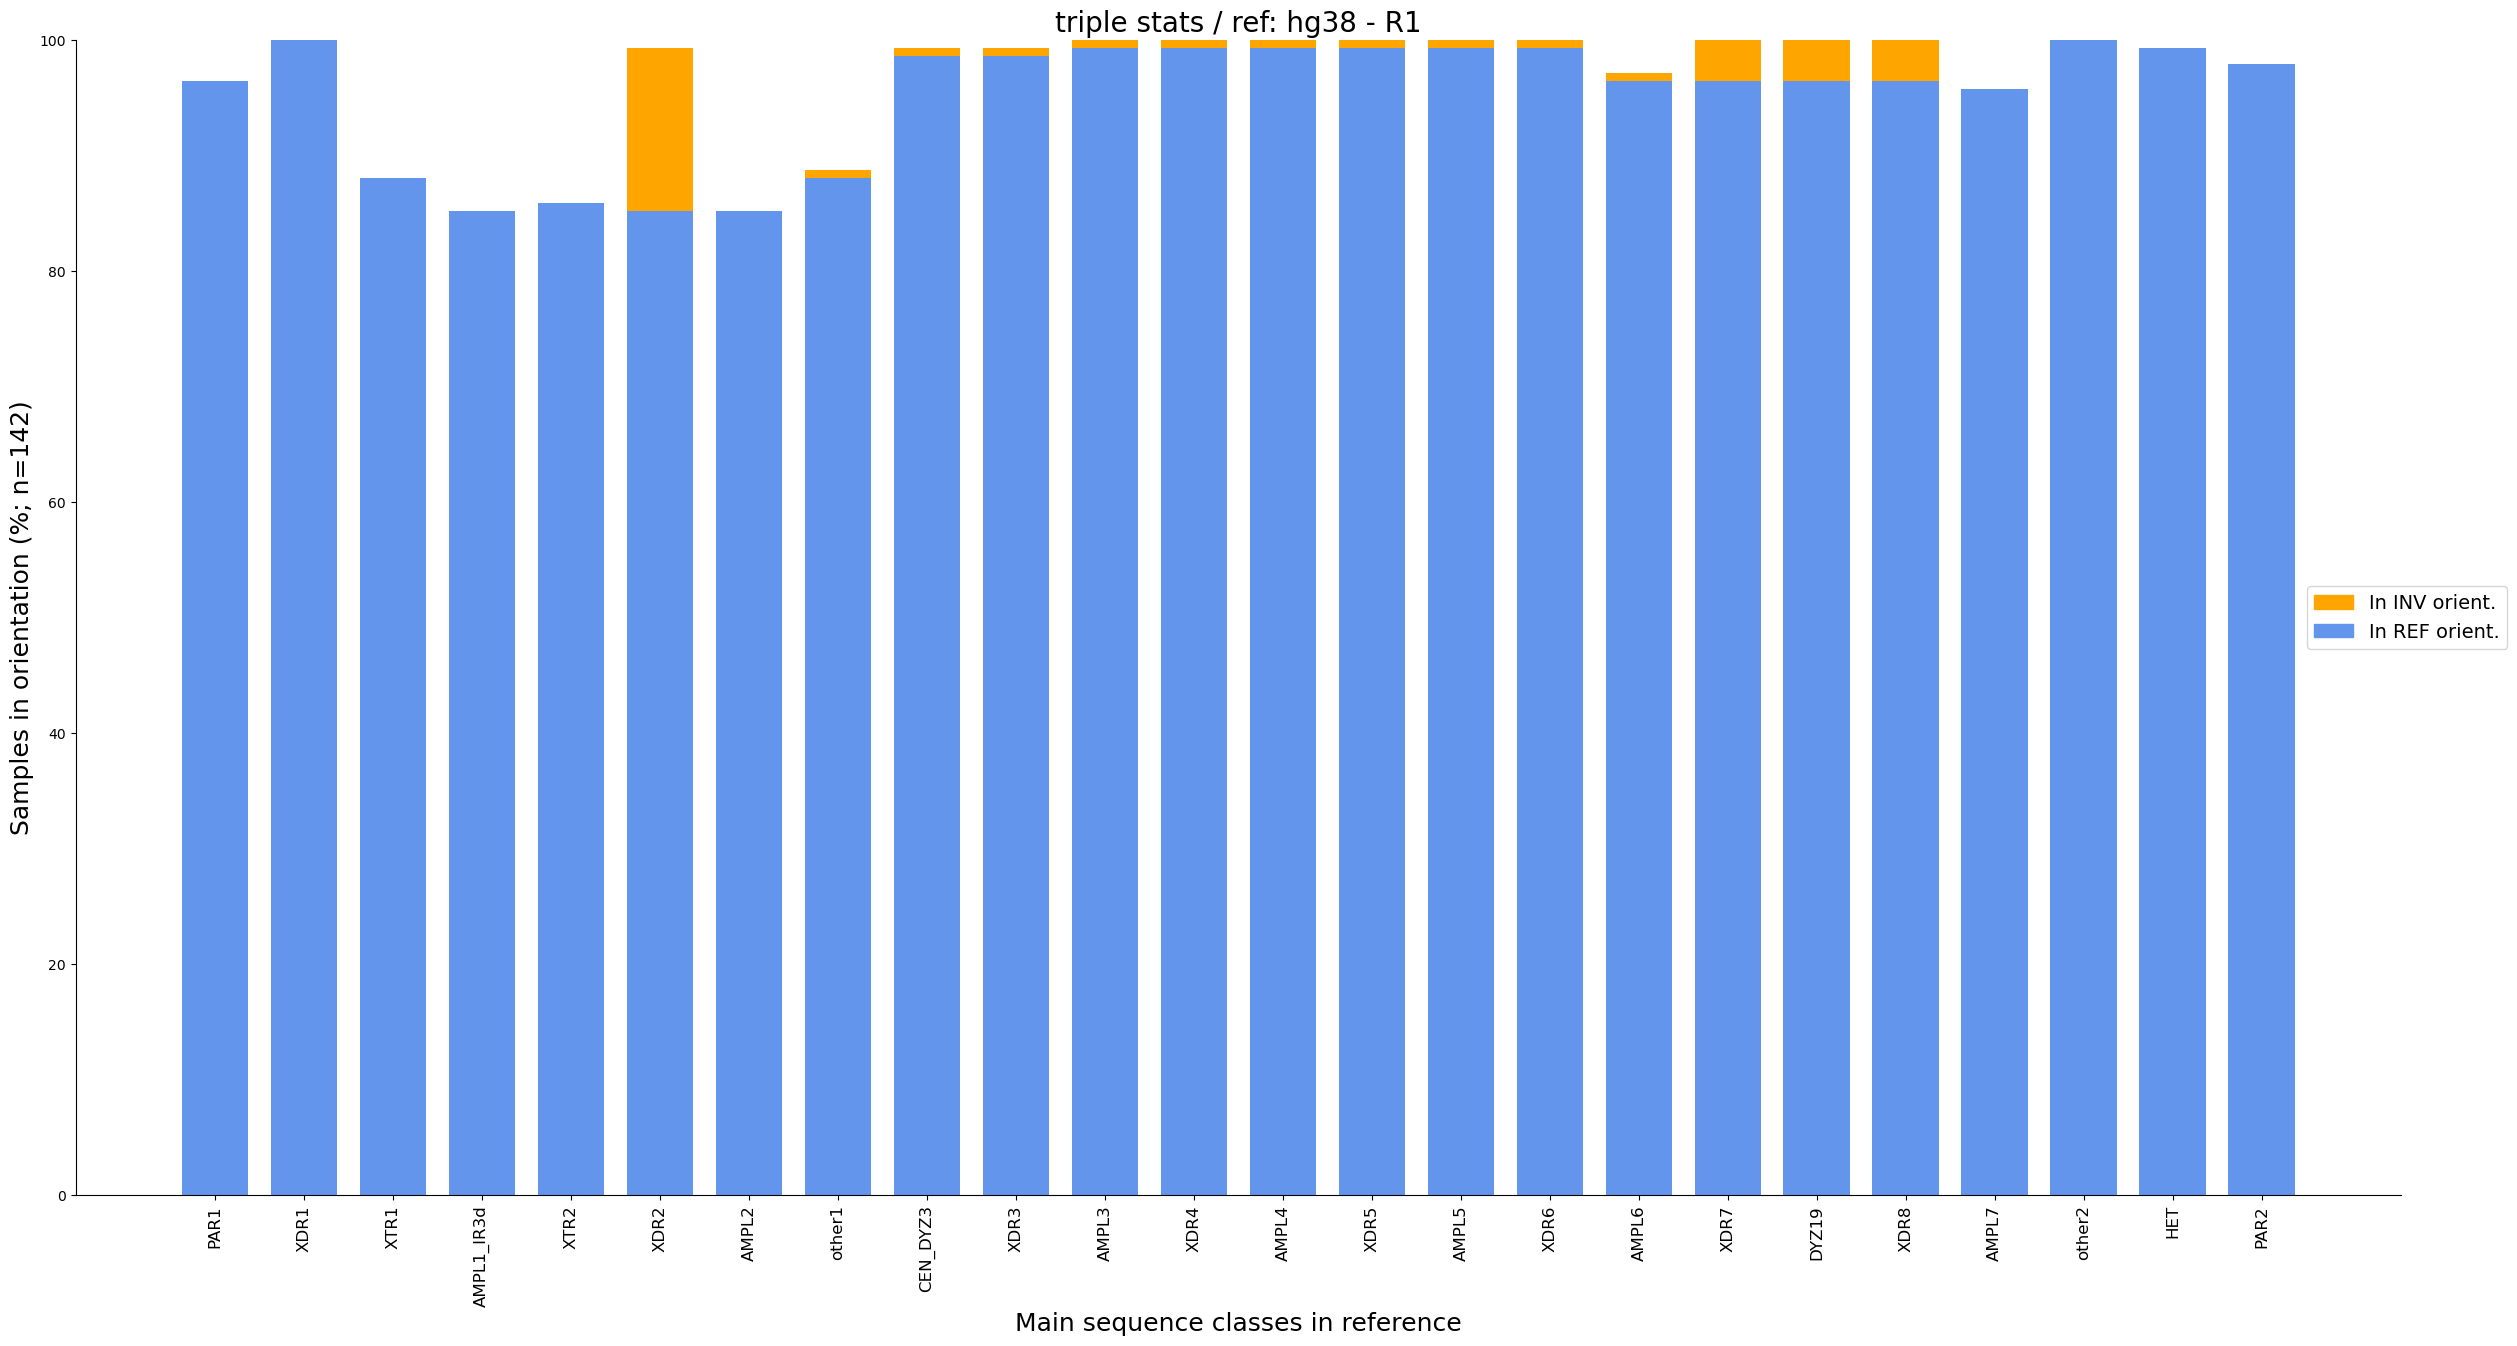

In [1]:
import pathlib as pl

cfg_nb = pl.Path("../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

print(DATA_ROOT)
print(PLOT_ROOT)

# actual NB code

import pandas as pd
import re
import itertools as itt
import enum
import collections as col

project_repo = pl.Path(
    "/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/raw"
)
inv_samples = "20260204_142males_HGSVC_HPRC_CEPH_241125_LargeStrRearr_META.tsv"
inv_table_file = project_repo.joinpath(inv_samples).resolve(strict=True)

inv_table = pd.read_csv(inv_table_file, sep="\t", header=0)
inv_table.rename(
    {
        "Phy_order": "phylo_order",
        "ID": "sample",
        "haplogroup_shortest": "hg_base",
        "haplogroup_short": "hg_short",
        "haplogroup_long": "hg",
        "Yp-Yq_INV": "Yp_Yq_INV",
        "AMPL1-AMPL2_INV": "AMPL1_AMPL2_INV",
        "AMPL6-AMPL7_INV": "AMPL6_AMPL7_INV"
    }, axis=1, inplace=True
)

ref_base_path = pl.Path("/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/norm")

label_base_path = pl.Path("/home/ebertp/work/projects/chrom-y-extended/wf-data/region-labels/final_annot/2026-02_final-rev")

ref_files = {
    "t2tv2": "HG002-Y_T2Tv2_regions_repeat-details.bed",
    "hg38": "GRCh38-Y_regions_repeat-details.bed"
}
ref_hg = {
    "t2tv2": "J1",
    "hg38": "R1"
}

class TripleCategories(enum.Enum):
    REF = 0
    INV = 1
    PRF = 2
    MIS = 3
    DRP = 4

categ = TripleCategories


def load_reference_labels(fpath):

    df = pd.read_csv(fpath, sep="\t", header=0)

    match_selected = re.compile("^[0-9]+[nu]{1}_")
    select_label = lambda label: match_selected.match(label) is not None

    ref_label_column = "seqclass"
    
    df["select_label"] = df["name"].apply(select_label)
    # for hg38: CEN1 - CEN2 are probably SAT in T2T
    # and this annotation was replaced by Glennis' CEN
    # annotation, so the labels do not exist in the samples
    df = df.loc[~df[ref_label_column].isin(["CEN1", "CEN2"]), :].copy()
    df = df.loc[df["select_label"], :].copy()
    # this drops the SAT labels in the T2T reference annotation
    df = df.drop_duplicates([ref_label_column], keep=False, inplace=False).reset_index(drop=True, inplace=False)
    df.drop(["fasta_header", "select_label"], axis=1, inplace=True)
    # return dataframe and column that contains
    # the relevant information / seq. class labels
    return df, ref_label_column


def select_sample_labels(fpath, ref_labels):

    df = pd.read_csv(fpath, sep="\t", header=0)
    df = df.loc[df["#seq"].str.endswith("_chrY"), :].copy()
    df["name"] = df["name"].replace({"DYZ19_Yq": "DYZ19", "CEN-DYZ3": "CEN_DYZ3"}, inplace=False)
    
    df["select_label"] = df["name"].isin(ref_labels)
    df = df.loc[df["select_label"], :].reset_index(drop=True, inplace=False)
    df.sort_values("start", inplace=True)
    sample_labels = []
    last_added = ""
    for row in df.itertuples():
        if row.name == last_added:
            continue
        else:
            sample_labels.append(row.name)
            last_added = row.name    
    return sample_labels


def create_triples(ref_labels):

    # add sentinels for boundaries to have a
    # triple centered on each ref label
    # note that NONE cannot be used here due
    # to sorting the triples later
    iter_labels = ["START"] + ref_labels + ["END"]
    iter_pos = [-99] + list(range(len(ref_labels))) + [99]

    def label_triple():
        for triple in zip(iter_labels, iter_labels[1:], iter_labels[2:]):
            yield triple
        return

    def pos_triple():
        for triple in zip(iter_pos, iter_pos[1:], iter_pos[2:]):
            yield triple
        return

    triples = set()
    pos_lut = dict()
    for tri_label, tri_pos in zip(label_triple(), pos_triple()):
        triples.add(tri_label)
        pos_lut[tri_label] = tri_pos
    return triples, pos_lut


def compute_triple_stats(sample, sample_labels, ref, reference_labels):

    missing_labels = sorted(set(reference_labels) - set(sample_labels))
    stats = dict()
    stats["ref"] = ref
    stats["sample"] = sample
    stats["missing_labels_n"] = len(missing_labels)
    if missing_labels:
        stats["missing_labels"] = ",".join(missing_labels)
    else:
        stats["missing_labels"] = "N/A"
    listing = []

    # create triples
    ref_triples, ref_pos = create_triples(reference_labels)
    sample_triples, _ = create_triples(sample_labels)
    
    # 1. check forward/ref orientation match
    matching_triples = sample_triples.intersection(ref_triples)
    stats[categ.REF.name] = len(matching_triples)

    for t in matching_triples:
        p1, p2, p3 = ref_pos[t]
        listing.append(
            (ref, sample, categ.REF.name, ",".join(t), p1, p2, p3)
        )

    # adjust triple sets to avoid double counting
    ref_triples -= matching_triples
    sample_triples -= matching_triples

    # 2. check reverse/inv orientation match
    inv_ref_triples = set(t[::-1] for t in ref_triples)
    
    matching_triples = sample_triples.intersection(inv_ref_triples)
    stats[categ.INV.name] = len(matching_triples)
    # can subtract as is from samples
    sample_triples -= matching_triples
    # need to subtract inv(triple) for reference
    matching_triples = set(t[::-1] for t in matching_triples)
    ref_triples -= matching_triples

    for t in matching_triples:
        p1, p2, p3 = ref_pos[t]
        listing.append(
            (ref, sample, categ.INV.name, ",".join(t), p1, p2, p3)
        )

    # 3. check configuration match
    # to be able to remove the matching triples,
    # don't do the matching with a set() op
    mix_ref_triples = [(tuple(sorted(t)), t) for t in ref_triples]
    mix_smp_triples = [(tuple(sorted(t)), t) for t in sample_triples]
    remove_ref = set()
    remove_smp = set()
    for smp_mix, smp_ord in mix_smp_triples:
        for ref_mix, ref_ord in mix_ref_triples:
            if smp_mix == ref_mix:
                remove_ref.add(ref_ord)
                remove_smp.add(smp_ord)
                break

    stats[categ.PRF.name] = len(remove_smp)

    for t in remove_ref:
        p1, p2, p3 = ref_pos[t]
        listing.append(
            (ref, sample, categ.PRF.name, ",".join(t), p1, p2, p3)
        )

    sample_triples -= remove_smp
    ref_triples -= remove_ref

    stats[categ.DRP.name] = len(sample_triples)

    for t in sample_triples:
        listing.append(
            (ref, sample, categ.DRP.name, ",".join(t), -99, -99, -99)
        )

    stats[categ.MIS.name] = len(ref_triples)
    for t in ref_triples:
        p1, p2, p3 = ref_pos[t]
        listing.append(
            (ref, sample, categ.MIS.name, ",".join(t), p1, p2, p3)
        )

    listing = pd.DataFrame.from_records(
        listing,
        columns=["ref", "sample", "triple_category", "triple", "ref_pos1", "ref_pos2", "ref_pos3"]
    )
    listing.sort_values(["ref_pos1", "ref_pos2", "ref_pos3"], inplace=True)

    return stats, listing
    
cohort_stats = []
cohort_listing = []
ref_label_lut = dict()

for ref, ref_file in ref_files.items():
    fp = ref_base_path.joinpath(ref_file)
    ref_labels, ref_label_column = load_reference_labels(fp)

    subfolder = label_base_path.joinpath(ref)
    ref_labels = ref_labels[ref_label_column].values.tolist()
    ref_label_lut[ref] = ref_labels
    for region_file in subfolder.glob("*.bed"):
        sample = region_file.name.split(".")[0]
        sample_labels = select_sample_labels(region_file, ref_labels)

        stats, listing = compute_triple_stats(sample, sample_labels, ref, ref_labels)
        cohort_listing.append(listing)
        cohort_stats.append(stats)

cohort_listing = pd.concat(cohort_listing, axis=0, ignore_index=False)
cohort_listing.sort_values(["ref", "sample", "ref_pos1", "ref_pos2", "ref_pos3"], inplace=True)
cohort_listing = cohort_listing.merge(inv_table, on="sample", how="outer")
out_tsv = DATA_ROOT.joinpath("nb-results", "label-triple-stats", "triple-listing.tsv")
cohort_listing.to_csv(out_tsv, sep="\t", header=True, index=False)

cohort_stats = pd.DataFrame.from_records(cohort_stats)
cohort_stats.sort_values(["ref", "sample"], ascending=[True, True], inplace=True)
cohort_stats = cohort_stats.merge(inv_table, on="sample", how="outer")
out_tsv = DATA_ROOT.joinpath("nb-results", "label-triple-stats", "triple-stats.tsv")
cohort_stats.to_csv(out_tsv, sep="\t", header=True, index=False)

agg = cohort_stats.groupby(["ref", "missing_labels", "AMPL1_AMPL2_INV"]).size()
#print(agg)

import matplotlib as mpl
import matplotlib.colors as mplcol
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import dataclasses as dcl
import numpy as np

@dcl.dataclass
class CNColors:
    REF = mplcol.to_rgb("cornflowerblue")
    INV = mplcol.to_rgb("orange")
    PRF = mplcol.to_rgb("magenta")
    DRP = mplcol.to_rgb("firebrick")
    MIS = mplcol.to_rgb("red")
    LAB = mplcol.to_rgb("grey")

    def get_color(self, cn):
        try:
            rgb = getattr(self, f"cn_{cn}")
        except AttributeError:
            raise
        return rgb

    def get_sorted_colors(self):
        return ["REF", "INV", "PRF", "DRP", "MIS", "LAB"]

    def get_color_labels(self):
        labels = [
            "In REF orient.",
            "In INV orient.",
            "Profile match",
            "Triple dropped from sample",
            "Missing ref. triple",
            "Missing label in sample"
        ]
        return labels

cn_colors = CNColors()

def create_stats_stacked_bar_chart():

    for ref, _ in ref_files.items():
        hg = ref_hg[ref]
    
        fig, ax = plt.subplots(figsize=(30,15))
        legend_elements = []
        
        sub = cohort_stats.loc[cohort_stats["ref"] == ref, :].copy()
        sub.sort_values("phylo_order", inplace=True)
        sub.rename({"missing_labels_n": "LAB"}, axis=1, inplace=True)
        bottom = np.zeros(sub.shape[0], dtype=int)
        x_pos = sub["phylo_order"].values
        labels = sub["hg_short"] + " - " + sub["sample"]
        type_colors = cn_colors.get_sorted_colors()
        color_labels = cn_colors.get_color_labels()
        for color, label in zip(type_colors, color_labels):
            rgb = getattr(cn_colors, color)
            bar_height = sub[color]
            ax.bar(
                x_pos,
                bar_height,
                bottom=bottom,
                align="center",
                width=0.75,
                facecolor=rgb
            )
            legend_elements.append(Patch(facecolor=rgb, edgecolor=rgb, label=label))
            bottom += bar_height
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=90, fontsize=12)
        ax.set_title(f"triple stats / ref: {ref} - {hg}", fontsize=20)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            handles=legend_elements[::-1], loc="right",
            bbox_to_anchor=(1.1, 0.5),
            fontsize=14
        )
        out_path = PLOT_ROOT.joinpath("triple-stats-barchart", f"triple-stats.sample-phylo.{ref}.png")
        out_path.parent.mkdir(exist_ok=True, parents=True)
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    return
    

def create_triple_centered_bar_chart():

    for ref, _ in ref_files.items():
        hg = ref_hg[ref]

        triples, ref_pos_lut = create_triples(ref_label_lut[ref])

        sub = cohort_listing.loc[cohort_listing["ref"] == ref, :].copy()

        x_pos = []
        x_labels = []
        pct_ref_match = []
        pct_inv_match = []
        denom = sub["sample"].nunique()
        for l, c, r in triples:
            # if l == "START" or r == "END":
            #     continue
            t = ",".join([l, c, r])
            _, c_pos, _ = ref_pos_lut[(l, c, r)]
            select_t = sub["triple"] == t
            select_ref_match = sub["triple_category"] == "REF"
            select_inv_match = sub["triple_category"] == "INV"

            n_ref = sub.loc[select_t & select_ref_match, "sample"].nunique()
            n_inv = sub.loc[select_t & select_inv_match, "sample"].nunique()
            pct_ref_match.append(round(n_ref/denom*100, 2))
            pct_inv_match.append(round(n_inv/denom*100, 2))
            x_labels.append(c)
            x_pos.append(c_pos)

        fig, ax = plt.subplots(figsize=(30,15))
        legend_elements = []
        bottom = np.zeros(len(x_labels), dtype=float)
        
        rgb = getattr(cn_colors, "REF")
        ax.bar(
            x_pos,
            pct_ref_match,
            bottom=bottom,
            align="center",
            width=0.75,
            facecolor=rgb
        )
        legend_elements.append(
            Patch(facecolor=rgb, edgecolor=rgb, label="In REF orient.")
        )
        bottom += pct_ref_match

        rgb = getattr(cn_colors, "INV")
        ax.bar(
            x_pos,
            pct_inv_match,
            bottom=bottom,
            align="center",
            width=0.75,
            facecolor=rgb
        )
        legend_elements.append(
            Patch(facecolor=rgb, edgecolor=rgb, label="In INV orient.")
        )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, rotation=90, fontsize=12)
        ax.set_title(f"triple stats / ref: {ref} - {hg}", fontsize=20)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            handles=legend_elements[::-1], loc="right",
            bbox_to_anchor=(1.05, 0.5),
            fontsize=14
        )
        ax.set_xlabel("Main sequence classes in reference", fontsize=18)
        ax.set_ylabel(f"Samples in orientation (%; n={denom})", fontsize=18)
        out_path = PLOT_ROOT.joinpath("triple-orient-barchart", f"triple-stats.seqclass-center.{ref}.png")
        out_path.parent.mkdir(exist_ok=True, parents=True)
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
            
            
            
create_stats_stacked_bar_chart()
create_triple_centered_bar_chart()
    
    
        